In [ ]:
import os
import warnings
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
warnings.filterwarnings("ignore")

import torch
import numpy as np
import cupy as cp
import wandb
from mrinufft import get_operator
from mrinufft.io import read_trajectory
from mrinufft.io.utils import add_phase_to_kspace_with_shifts
from mrinufft.extras.smaps import cartesian_espirit, coil_compression
from baselines.grappa_reconstruction import do_grappa_and_append_data
from utils import MRINUFFTPhysicsRI, ri_to_complex, complex_to_ri, psnr, ssim, _load_volumes, L2_precon, normalize_kspace, get_acs_locations, get_DPIR_params
from reg_architecture import WCRR3D
from deepinv.optim.prior import PnP, WaveletPrior
from deepinv.optim import HQS, FISTA
from baselines.drunet.drunet_base import DRUNet
from baselines.PostProcess.drunet3d import DRUNet3D
from baselines.ncpdnet import NCPDNET
from baselines.TV import PDHG_TV
import yaml
from baselines.NCSNpp2D.ncsnpp2D import build_model_from_config
from baselines.NCSNpp2D.DiffMBIR import diffmbir
from mrinufft.extras.cartesian import fft, ifft
from mrinufft.extras.smaps import get_smaps
from evaluation.nmAPG3d import reconstruct_nmAPG
import gc

torch.random.manual_seed(0)  # make results deterministic

coil = 20 # 12 or 32 or different for prospective users
method = "wcrr" # "wcrr", "tv", "wv", "drunet" or "ncpdnet" or "score-diff" or "postprocess"
root = "/LOCAL/mri_data/prospective/"
traj = "d3_ICar_TW0_Nc65_Ns416_N256_OSF2_bOSF0.25_c63.0_d1.67_G2x2_ACS0x0_cOS1.0__D20M6Y2025T914.bin" #gs.bin

volume_id = -1  
os.makedirs(f"prospective_{coil}coil_gs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backend = "cufinufft" # "gpunufft"
scaler = 1e-6 # data normalizer
noise_level = 2e-3
max_iter = 500 # Maximum number of iterations
data_fidelity = L2_precon(weights=torch.tensor(1.0))

# your 50 multi-coil volumes (12 or 32 coils)
volumes = sorted([fn for fn in os.listdir(root) if fn.endswith(".dat")])

print(volumes)

['meas_MID00095_FID12675_CAIPI_R3x2.dat', 'meas_MID00529_FID04255_SPARK_SqNc65_G2x2d1_TW0.dat']


In [84]:
import os
os.listdir(f"/LOCAL/mri_data/prospective")

['caipi3x2.bin',
 'meas_MID00529_FID04255_SPARK_SqNc65_G2x2d1_TW0_ref.nii',
 'meas_MID00095_FID12675_CAIPI_R3x2.dat',
 'meas_MID00529_FID04255_SPARK_SqNc65_G2x2d1_TW0_ref.nii.gz',
 'meas_MID00529_FID04255_SPARK_SqNc65_G2x2d1_TW0.dat',
 'd3_ICar_TW0_Nc65_Ns416_N256_OSF2_bOSF0.25_c63.0_d1.67_G2x2_ACS0x0_cOS1.0__D20M6Y2025T914.bin',
 'meas_MID00095_FID12675_CAIPI_R3x2_ref.nii',
 'meas_MID00095_FID12675_CAIPI_R3x2_ref.nii.gz']

In [83]:
os.rename(f"/LOCAL/mri_data/prospective/caipi_3x2_circ_1min.bin", f"/LOCAL/mri_data/prospective/caipi3x2.bin")

In [3]:
import os
import shutil
import numpy as np
import nibabel as nib
from mrinufft.io import read_arbgrad_rawdat



def is_gzip_file(path):
    with open(path, "rb") as f:
        return f.read(2) == b"\x1f\x8b"


def load_nifti_maybe_wrong_gz(path):
    """
    Load a NIfTI file even if it is named .nii.gz but is actually uncompressed .nii.
    """

    if not os.path.exists(path):
        raise FileNotFoundError(f"Reference file not found: {path}")

    # Case 1: correctly compressed .nii.gz
    if path.endswith(".nii.gz") and is_gzip_file(path):
        img = nib.load(path)
        return np.asanyarray(img.dataobj).astype(np.complex64)

    # Case 2: file is named .nii.gz but is actually plain .nii
    if path.endswith(".nii.gz") and not is_gzip_file(path):
        fixed_path = path[:-3]  # remove ".gz", gives ".nii"

        if not os.path.exists(fixed_path):
            shutil.copy(path, fixed_path)

        img = nib.load(fixed_path)
        return np.asanyarray(img.dataobj).astype(np.complex64)

    # Case 3: normal .nii
    img = nib.load(path)
    return np.asanyarray(img.dataobj).astype(np.complex64)

def _load_volumes(filename):
    if filename.endswith(".dat"):
        kspace_data, data_header = read_arbgrad_rawdat(filename)

        ref_path = filename.replace(".dat", "_ref.nii.gz")

        data_header["ref"] = load_nifti_maybe_wrong_gz(ref_path)

        return (
            kspace_data.astype(np.complex64).reshape(kspace_data.shape[0], -1),
            data_header,
        )

    else:
        raise ValueError(f"Unsupported file type: {filename}")
    
    
y, data_header = _load_volumes(os.path.join(root, volumes[1]))

pymapVBVD version 0.6.1
Software version: VD


In [ ]:
idx = 0 # 1 for gs and 0 for caipi
y, data_header = _load_volumes(os.path.join(root, volumes[idx]))
y = y  * 1e3 #/ 0.9 # Scale real data to same scale as simulations
C, *XYZ = data_header['ref'].shape
x = torch.tensor(data_header['ref'], dtype=torch.complex64).moveaxis((0, -1),(-1, 0)) # Ground truth image
traj, traj_params = read_trajectory(os.path.join(root, data_header['trajectory_name']), dwell_time=0.01/data_header['oversampling_factor'])
caipi_delta = 1
y = add_phase_to_kspace_with_shifts(
    y, 
    traj.reshape(-1, traj_params["dimension"]),
    normalized_shifts=(
        np.array(data_header["shifts"])
        / np.array(traj_params["FOV"])
        * np.array(traj_params["img_size"])
        / 1000
    ),
)
y = torch.from_numpy(y)
traj[traj < -0.5] = -0.5
traj[traj > 0.5] = 0.5
kspace_loc = traj.reshape(-1, traj_params["dimension"])
# @Shama you can use ESPIRiT like this to get the smaps from the acs data in data_header['acs'], we started doing external ACS acquisitions for all current acquisitions
C, *XYZ = data_header['acs'].shape
smaps = cartesian_espirit(cp.asarray(data_header['acs'], dtype=cp.complex64), traj_params['img_size'], decim=4, crop=0).get()
# Clean up cupy memory
cp._default_memory_pool.free_all_blocks()
coils = y.shape[0]
F_raw = get_operator(backend)(kspace_loc, x.shape, n_coils=coils, density=True, squeeze_dims=True) # NUFFT operator that simulates the measurement (takes coil images as input, outputs k-space)


pymapVBVD version 0.6.1
Software version: VD


ValueError: operands could not be broadcast together with shapes (18,5857280) (4579328,) 

: 

In [5]:
x_ = torch.flip(x, dims=[0])

In [77]:
# Operator definition
import time


E_est = get_operator(backend)(
    kspace_loc,
    x.shape,
    n_coils=coils,
    smaps=smaps,
    squeeze_dims=True,
)
physics = MRINUFFTPhysicsRI(E_est)
print("Succesfull!")

t1_sense = time.time()
sense_ri = physics.A_dagger(y)
dt_init = time.time() - t1_sense
init = sense_ri # Initialization for all our iterative methods
init_recon = torch.abs(ri_to_complex(init))

# Reference/Ground Truth (Adjoint coil combination)
x_gt = x
x_gt_ri = complex_to_ri(x_gt) # In the RI space
reference = torch.abs(ri_to_complex(x_gt_ri))

# Clean memory before proper reconstructions
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
cp._default_memory_pool.free_all_blocks()
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

Succesfull!


100%|██████████| 10/10 [00:21<00:00,  2.16s/it]


### TV recon

In [6]:
op_norm = physics.compute_sqnorm(torch.randn_like(x_gt_ri, device=device), max_iter=20).item()

In [7]:
op_norm

0.8938701152801514

In [8]:
lmbd =  3e-4
tol = 1e-4

solver_tv = PDHG_TV(
    lambda_reg=lmbd,
    max_iter=max_iter,
    lipschitz= op_norm,
    data_fidelity=data_fidelity,
    stopping_criterion=tol,
)
with torch.no_grad():
    t1_tv = time.time()
    x_rec_ri_tv = solver_tv(y.to(device), physics, init=init.to(device), compute_metrics=False).detach().cpu()
    dt = time.time() - t1_tv
tv_recon  = torch.abs(ri_to_complex(x_rec_ri_tv)) # Its magnitude

 43%|████▎     | 215/500 [07:20<09:43,  2.05s/it]

Converged at iteration: 216


In [ ]:
torch.save(tv_recon, f"prospective_{coil}coil_gs/volume_gs_tv.pt")

In [18]:
x = torch.flip(x_gt, dims=[0])

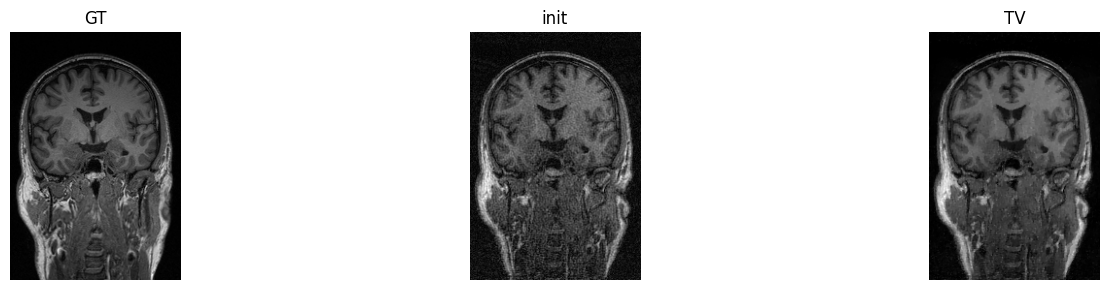

In [10]:
import matplotlib.pyplot as plt

# Plots (sagittal mid-slice)
mid =  x_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(x.abs()[:,mid,:].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(init_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('init'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(tv_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('TV'); plt.axis('off')
plt.tight_layout(); plt.show()

### WV recon

In [15]:
prior_wv = WaveletPrior(level=4, wv="db4", p=1, wvdim=3)
lmbd = 1e-2
tol = 1e-4

solver_wv = FISTA(
    prior=prior_wv,
    data_fidelity=data_fidelity,
    stepsize=1.0 / op_norm,
    lambda_reg=lmbd,
    max_iter=max_iter,
    thres_conv=tol,
    verbose=True,
    early_stop=True,
    show_progress_bar=True,
)
with torch.no_grad():
    t1_wv = time.time()
    x_rec_ri_wv = solver_wv(y.to(device), physics, init=(init.to(device), init.to(device)), compute_metrics=False).detach().cpu()
    dt = time.time() - t1_wv
wv_recon  = torch.abs(ri_to_complex(x_rec_ri_wv)) # Its magnitude

 77%|███████▋  | 386/500 [17:20<05:07,  2.69s/it]

Iteration 386, current converge crit. = 9.99E-05, objective = 1.00E-04 


In [17]:
torch.save(wv_recon, f"prospective_{coil}coil_gs/volume_gs_wv.pt")

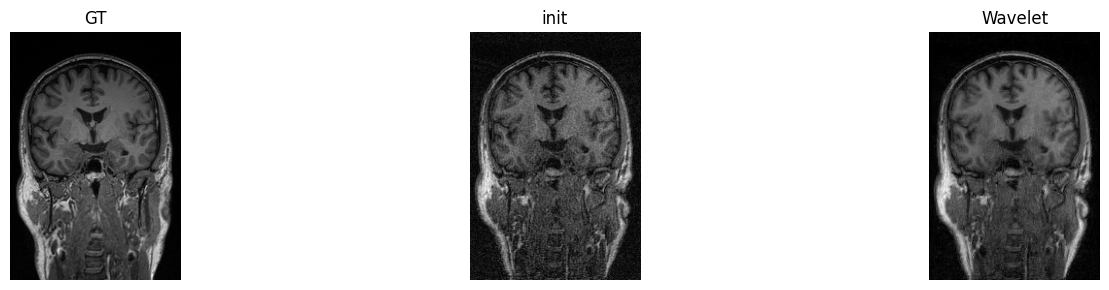

In [16]:
# Plots (sagittal mid-slice)
mid =  x_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(x.abs()[:,mid,:].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(init_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('init'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(wv_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('Wavelet'); plt.axis('off')
plt.tight_layout(); plt.show()

### WCRR recon

In [18]:
regularizer = WCRR3D(weak_convexity=1.0, nb_channels=[2,4,8,16], filter_sizes=[3, 3, 3], rotations=True).to(device)
regularizer.load_state_dict(torch.load("weights/bilevel_Denoising/WCRR_16_bilevel_IFT_ckpt_500.pt", weights_only=True, map_location=device))
regularizer.eval()
lmbd = 0.01
sigma = 0.06 #0.03
sigma = torch.tensor([sigma], device=device)
tol = 1e-4

with torch.no_grad():
    t1_wcrr = time.time()
    x_rec_ri_wcrr = reconstruct_nmAPG(
            sigma,
            y.unsqueeze(0).to(device),
            physics,
            data_fidelity,
            regularizer,
            lmbd,
            1e-1, # Stepsize_nmAPG (can be anything)
            max_iter,
            tol,
            verbose=True,
            x_init=init.to(device),
            return_stats=False,
            ).detach().cpu()
    dt = time.time() - t1_wcrr                 
wcrr_recon  = torch.abs(ri_to_complex(x_rec_ri_wcrr)) # Its magnitude

 33%|███▎      | 164/500 [10:38<21:49,  3.90s/it]

Converged in iter 164, tol 0.000099


In [21]:
torch.save(wcrr_recon, f"prospective_{coil}coil_gs/volume_gs_wcrr.pt")

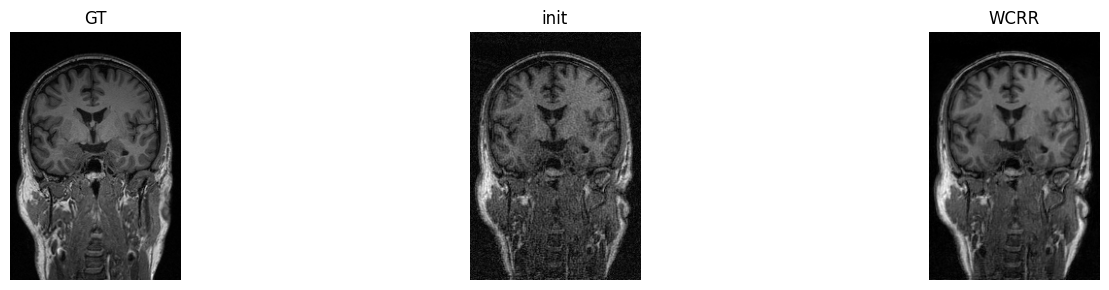

In [20]:
# Plots (sagittal mid-slice)
mid =  x_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(x.abs()[:,mid,:].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(init_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('init'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(wcrr_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('WCRR'); plt.axis('off')
plt.tight_layout(); plt.show()

### DPIR recon

In [6]:
drunet = DRUNet(in_channels=2, out_channels=2, dim=3, pretrained=None).to(device)
drunet.load_state_dict(torch.load("weights/drunet/drunet_3d_complex_denoise.pth", map_location=device, weights_only=True))
prior_drunet = PnP(denoiser=drunet.eval())
sigma_denoiser, stepsize, num_iter = get_DPIR_params(num_iter=8, sigma=5e-3, lmbd=5.5, sigma_init=0.01)
solver_drunet = HQS(
        prior=prior_drunet,
        data_fidelity=data_fidelity,
        stepsize=stepsize,
        sigma_denoiser=sigma_denoiser,
        max_iter=num_iter,
        verbose=True,
        show_progress_bar = True,
    )

In [7]:
with torch.no_grad():
    t1_drunet = time.time()
    x_rec_ri_drunet = solver_drunet(y.to(device), physics, init=init.to(device), compute_metrics=False).detach().cpu()
    dt = time.time() - t1_drunet
dpir_recon  = torch.abs(ri_to_complex(x_rec_ri_drunet)) # Its magnitude

100%|██████████| 8/8 [05:25<00:00, 40.70s/it]


In [12]:
torch.save(dpir_recon, f"prospective_{coil}coil_gs/volume_gs_dpir.pt")

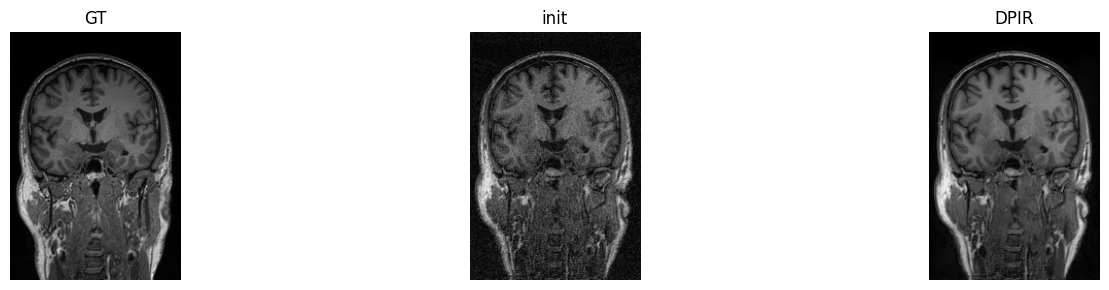

In [14]:
from matplotlib import pyplot as plt
# Plots (sagittal mid-slice)
mid =  x_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(x.abs()[:,mid,:].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(init_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('init'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(dpir_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('DPIR'); plt.axis('off')
plt.tight_layout(); plt.show()

### Score-diff recon

In [7]:
cfg = yaml.safe_load(open("baselines/NCSNpp2D/ncsnpp2D.yaml"))
ckpt = torch.load("weights/NCSNpp2D/ckpt_0035000.pt", map_location=device)

model = build_model_from_config(cfg).to(device)
model.load_state_dict(ckpt["model"], strict=True)

# overwrite model weights by EMA weights
sd = model.state_dict()
for k, v in ckpt["ema"].items():
    sd[k].copy_(v.to(device))
model.load_state_dict(sd)
model.eval()

NCSNpp2D(
  (time_embed): Sequential(
    (0): GaussianFourierProjection()
    (1): Linear(in_features=256, out_features=384, bias=True)
    (2): SiLU()
    (3): Linear(in_features=384, out_features=384, bias=True)
  )
  (in_conv): Conv2d(2, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down): ModuleList(
    (0): ModuleList(
      (0-3): 4 x ModuleList(
        (0): ResBlock(
          (norm1): GroupNorm(32, 96, eps=1e-05, affine=True)
          (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (emb): Linear(in_features=384, out_features=192, bias=True)
          (norm2): GroupNorm(32, 96, eps=1e-05, affine=True)
          (drop): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (skip): Identity()
        )
        (1): Identity()
      )
    )
    (1): ModuleList(
      (0): ModuleList(
        (0): ResBlock(
          (norm1): GroupNorm(32, 96, eps=1e-05, affine

In [8]:
op_norm = physics.compute_sqnorm(torch.randn_like(x_gt_ri, device=device), max_iter=20).item()
op_norm

0.8938702344894409

In [62]:
with torch.no_grad():
    t1_scorediff = time.time()
    x_rec_ri = diffmbir(model, physics, y.to(device), init.to(device),
            sigma_max=0.015,sigma_min=0.005,num_steps=8,#6,
            dc_steps=3, dc_lr=1.0 * op_norm, z_weight=1e-2 * op_norm,
        ).detach().cpu()
    dt = time.time() - t1_scorediff
diff_recon  = torch.abs(ri_to_complex(x_rec_ri)) # Its magnitude

100%|██████████| 8/8 [01:12<00:00,  9.01s/it]


In [66]:
torch.save(diff_recon, f"prospective_{coil}coil_gs/volume_gs_diff.pt")

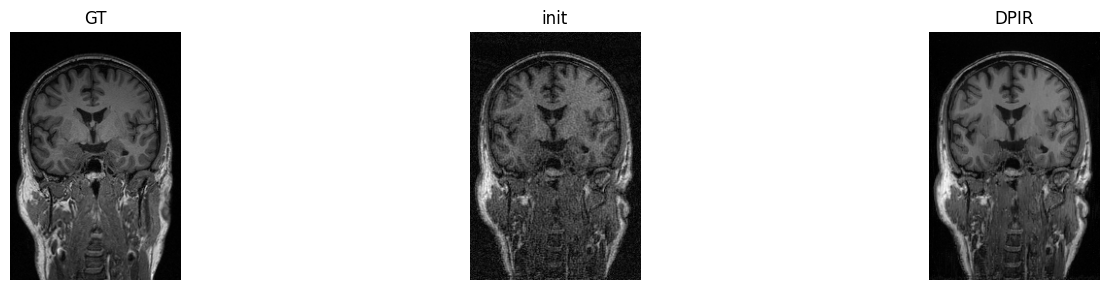

In [63]:
import matplotlib.pyplot as plt
# Plots (sagittal mid-slice)
mid =  x_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(x.abs()[:,mid,:].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(init_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('init'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(diff_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('DPIR'); plt.axis('off')
plt.tight_layout(); plt.show()

In [72]:
crop_ncpdnet = center_crop_3d(ncpdnet_recon, 64)
crop_diff = center_crop_3d(diff_recon, 64)
crop_init = center_crop_3d(init_recon, 64)
crop_gt = center_crop_3d(x.abs(), 64)

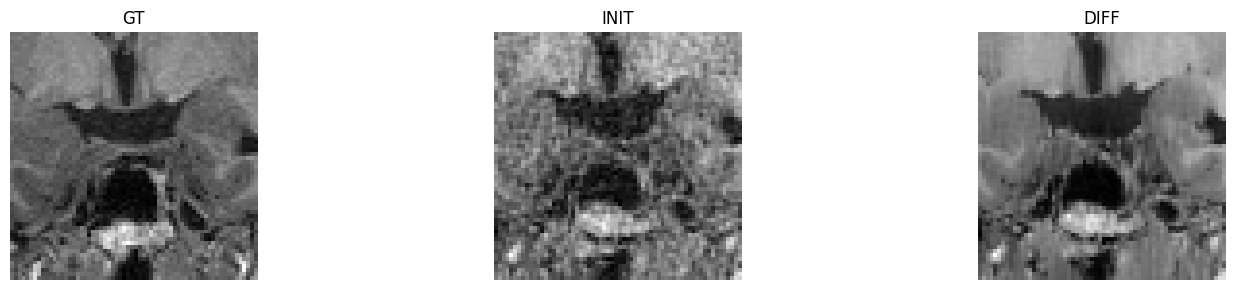

In [64]:
import matplotlib.pyplot as plt
# Plots (sagittal mid-slice)
mid =  crop_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(crop_gt[:,mid, :].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(crop_init[:,mid, :].cpu(),  cmap='gray'); plt.title('INIT'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(crop_diff[:,mid, :].cpu(),  cmap='gray'); plt.title('DIFF'); plt.axis('off')
plt.tight_layout(); plt.show()

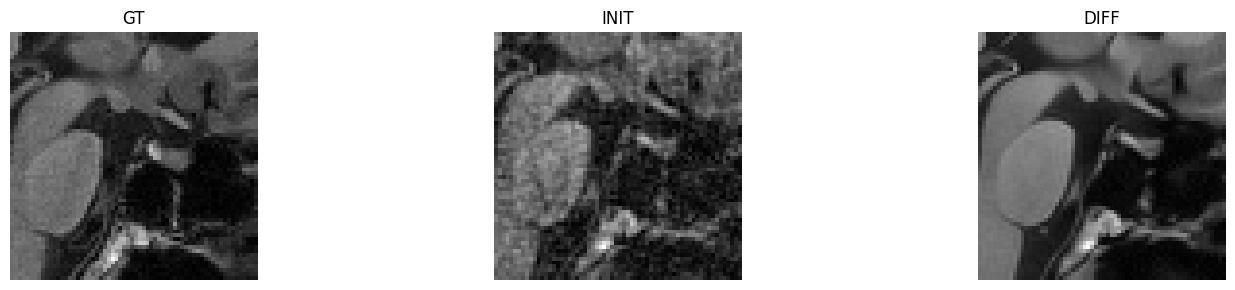

In [65]:
import matplotlib.pyplot as plt
# Plots (sagittal mid-slice)
mid =  crop_gt.shape[-1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(crop_gt[...,mid].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(crop_init[...,mid].cpu(),  cmap='gray'); plt.title('INIT'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(crop_diff[...,mid].cpu(),  cmap='gray'); plt.title('DIFF'); plt.axis('off')
plt.tight_layout(); plt.show()

In [12]:
def center_crop_3d(x, size):
    D, H, W = x.shape
    if isinstance(size, int):
        size = (size, size, size)

    d, h, w = size
    d0 = (D - d) // 2
    h0 = (H - h) // 2
    w0 = (W - w) // 2

    return x[d0:d0+d, h0:h0+h, w0:w0+w]

### NC-PDNet recon

In [69]:
class DummyNUFFT:
    def op(self, x):
        return x  
    def adj_op(self, kspace, dcomp=None):
        return torch.zeros_like(kspace)
dummy_nufft = DummyNUFFT()
ncpdnet = NCPDNET(nufft_op=dummy_nufft, image_net_type="ImageNetUnet", base_filters=16, num_stages=3, n_primal=2, n_iter=6, activation="silu", dim=3, complex_recon=True, normalize_input=True)
weights = torch.load("weights/ncpdnet/NCPDNetWeights67.pth", map_location=device, weights_only=True)
ncpdnet.load_state_dict(weights["state_dict"])


<All keys matched successfully>

In [70]:
# NC-PDNet is trained with Density compensation
samples = torch.from_numpy(E_est.samples.get()).to(dtype=torch.float32)
yn, norm_fact = normalize_kspace(y, samples)
# Make norm_fact safe and float32
if not torch.is_tensor(norm_fact):
    norm_fact_t = torch.tensor(norm_fact, device=device, dtype=torch.float32)
else:
    norm_fact_t = norm_fact.to(device=device, dtype=torch.float32)
# Force k-space to complex64 on GPU
y = yn.to(device=device, dtype=torch.complex64)
# Force initialization to complex64 on GPU
init_cplx = ri_to_complex(init).to(device=device, dtype=torch.complex64)[None, None]
init_cplx = init_cplx / norm_fact_t
E_est.squeeze_dims = False  # preserve batch dim for ncpdnet
ncpdnet.update_nufft_op(E_est)
ncpdnet.to(device=device, dtype=torch.float32).eval()

with torch.no_grad():
    t1_ncpdnet = time.time()
    recon = ncpdnet(
        y.unsqueeze(0),
        init_cplx,
    ).squeeze().detach().cpu()

    ncpdnet_recon = torch.abs(recon) * norm_fact_t.detach().cpu()
    dt = time.time() - t1_ncpdnet

In [74]:
torch.save(ncpdnet_recon, f"prospective_{coil}coil_gs/volume_gs_ncpdnet.pt")

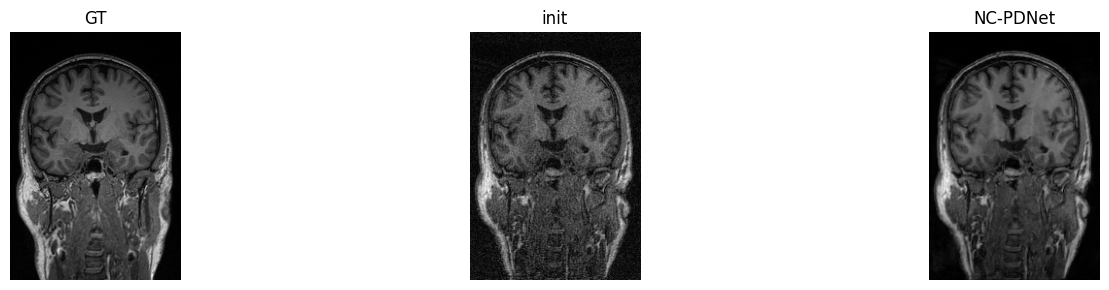

In [71]:
# Plots (sagittal mid-slice)
mid =  x_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(x.abs()[:,mid,:].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(init_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('init'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(ncpdnet_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('NC-PDNet'); plt.axis('off')
plt.tight_layout(); plt.show()

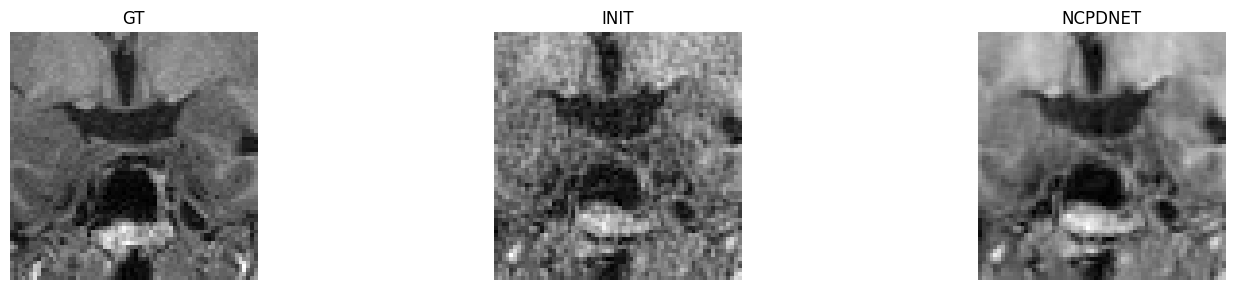

In [73]:
import matplotlib.pyplot as plt
# Plots (sagittal mid-slice)
mid =  crop_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(crop_gt[:,mid, :].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(crop_init[:,mid, :].cpu(),  cmap='gray'); plt.title('INIT'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(crop_ncpdnet[:,mid, :].cpu(),  cmap='gray'); plt.title('NCPDNET'); plt.axis('off')
plt.tight_layout(); plt.show()

### DRUNet3D recon

In [75]:
# model and reconstructor (use deepinv's DRUNet 3D)
net = DRUNet3D(in_channels=2, out_channels=2, pretrained=None, dim=3)
net.load_state_dict(torch.load("weights/PostProcess/ckp_epoch_500.pt", map_location=device, weights_only=True)["model"])
net.to(device)
net.eval()

DRUNet3D(
  (m_head): Conv3d(3, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (m_down1): Sequential(
    (0): ResBlock(
      (res): Sequential(
        (0): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
    )
    (1): ResBlock(
      (res): Sequential(
        (0): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
    )
    (2): ResBlock(
      (res): Sequential(
        (0): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
   

In [78]:
with torch.no_grad():
    t1_postprocess = time.time()
    zf_ri = physics.A_adjoint(y)
    x_rec_ri = net(zf_ri.to(device)).detach().cpu()
    dt = time.time() - t1_postprocess
    postprocess_recon  = torch.abs(ri_to_complex(x_rec_ri)) # Its magnitude


In [81]:
torch.save(postprocess_recon, f"prospective_{coil}coil_gs/volume_gs_postprocess.pt")

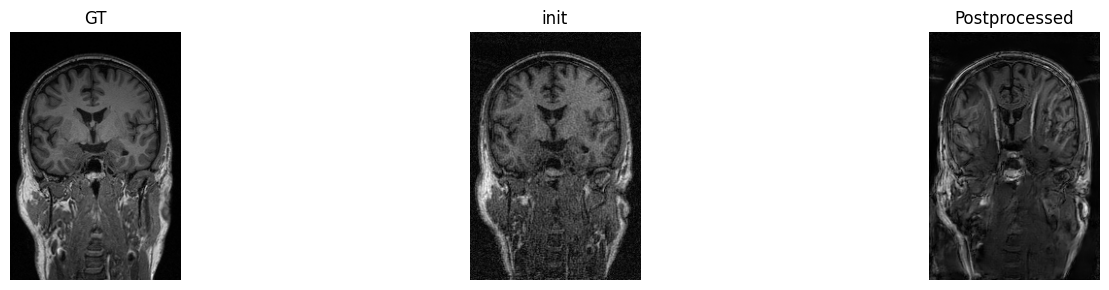

In [80]:
# Plots (sagittal mid-slice)
mid =  x_gt.shape[1] // 2
plt.figure(figsize=(16,3))
plt.subplot(1,3,1); plt.imshow(x.abs()[:,mid,:].cpu(), cmap='gray'); plt.title('GT'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(init_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('init'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(postprocess_recon[:,mid,:].cpu(),  cmap='gray'); plt.title('Postprocessed'); plt.axis('off')
plt.tight_layout(); plt.show()